In [33]:
import pandas as pd
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/PengamanJaringan/dataset/feature_vectors_syscallsbinders_frequency_5_Cat.csv')
data

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11593,2,0,0,11,0,61,13,0,66,17,...,0,0,0,0,0,0,10,2764,236,5
11594,6,0,0,10,1,69,50,1,118,15,...,0,0,0,0,1,0,5,4417,295,5
11595,0,0,0,0,0,21,16,0,48,9,...,0,0,0,0,0,0,5,241,67,5
11596,1,0,0,15,0,90,80,0,239,50,...,0,0,0,0,0,0,3,1703,774,5


In [34]:
data.isnull().sum()

ACCESS_PERSONAL_INFO___    0
ALTER_PHONE_STATE___       0
ANTI_DEBUG_____            0
CREATE_FOLDER_____         0
CREATE_PROCESS`_____       0
                          ..
watchRotation              0
windowGainedFocus          0
write                      0
writev                     0
Class                      0
Length: 471, dtype: int64

In [35]:
data['Class'].value_counts()

Class
3    3904
4    2546
2    2100
5    1795
1    1253
Name: count, dtype: int64

In [36]:
severity_map = {
    1: 0,  # Sehat
    2: 1,  # Level 1
    3: 2,  # Level 2
    4: 3,  # Level 3
    5: 4   # Level 4
}

data['Class'] = data['Class'].map(severity_map)

# Verifikasi
print(data['Class'].value_counts())
print(f"\nTotal : {len(data):,}")

Class
2    3904
3    2546
1    2100
4    1795
0    1253
Name: count, dtype: int64

Total : 11,598


In [37]:
from sklearn.model_selection import train_test_split

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (9278, 470)
Shape of X_test: (2320, 470)
Shape of y_train: (9278,)
Shape of y_test: (2320,)


In [38]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,f1_score, classification_report

In [39]:
class_labels = list(y_train.unique())
class_labels

[np.int64(2), np.int64(1), np.int64(0), np.int64(3), np.int64(4)]

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time


# ── Helper ──────────────────────────────────────────────────────────────────
def print_metrics(name, y_true, y_pred, training_time=None, testing_time=None):
    print(f"\n{'='*50}")
    print(f"  {name} Results")
    print(f"{'='*50}")
    if training_time is not None:
        print(f"  Training Time : {training_time:.4f}s")
    if testing_time is not None:
        print(f"  Testing Time  : {testing_time:.4f}s")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Precision Macro : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Recall Macro   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  F1-Score Macro : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=[str(x) for x in class_labels], zero_division=0))

# 1. Random Forest Classifier
print("\n--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
start = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
y_pred_rf = rf_model.predict(X_test)
rf_test_time = time.time() - start

print_metrics("Random Forest", y_test, y_pred_rf, training_time=rf_time, testing_time=rf_test_time)

# 2. XGBoost Classifier
print("\n--- Training XGBoost Classifier ---")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.2,
    random_state=42
)
start = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

start = time.time()
y_pred_xgb = xgb_model.predict(X_test)
xgb_test_time = time.time() - start

print_metrics("XGBoost", y_test, y_pred_xgb, training_time=xgb_time, testing_time=xgb_test_time)

# 3. LightGBM Classifier
print("\n--- Training LightGBM Classifier ---")
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=None,
    learning_rate=0.2,
    class_weight='balanced',
    random_state=42,
    verbose = -1
)
start = time.time()
lgbm_model.fit(X_train, y_train)
lgbm_time = time.time() - start

start = time.time()
y_pred_lgbm = lgbm_model.predict(X_test)
lgbm_test_time = time.time() - start

print_metrics("LightGBM", y_test, y_pred_lgbm, training_time=lgbm_time, testing_time=lgbm_test_time)


--- Training Random Forest Classifier ---

  Random Forest Results
  Training Time : 3.2475s
  Testing Time  : 0.0465s
  Accuracy  : 0.9483
  Precision : 0.9495
  Precision Macro : 0.9364
  Recall    : 0.9483
  Recall Macro   : 0.9409
  F1-Score  : 0.9483
  F1-Score Macro : 0.9380

  Classification Report:

              precision    recall  f1-score   support

           2       0.87      0.94      0.90       251
           1       0.97      0.90      0.93       420
           0       0.98      0.99      0.98       781
           3       0.96      0.92      0.94       509
           4       0.91      0.95      0.93       359

    accuracy                           0.95      2320
   macro avg       0.94      0.94      0.94      2320
weighted avg       0.95      0.95      0.95      2320


--- Training XGBoost Classifier ---

  XGBoost Results
  Training Time : 5.2473s
  Testing Time  : 0.0248s
  Accuracy  : 0.9522
  Precision : 0.9523
  Precision Macro : 0.9426
  Recall    : 0.9522
  R

In [41]:
# ── Rekap Perbandingan Semua Model ─────────────────────────────────────────
import pandas as pd

def collect_metrics(name, y_true, y_pred, train_time=None, test_time=None):
    return {
        "Model"              : name,
        "F1 Macro"           : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        "F1 Weighted"        : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall Macro"       : recall_score(y_true, y_pred, average='macro',    zero_division=0),
        "Recall Weighted"    : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Precision Macro"    : precision_score(y_true, y_pred, average='macro',    zero_division=0),
        "Precision Weighted" : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Accuracy"           : accuracy_score(y_true, y_pred),
        "Train Time (s)"     : round(train_time, 4) if train_time is not None else None,
        "Test Time (s)"      : round(test_time, 4) if test_time is not None else None,
    }

results = [
    collect_metrics("Random Forest", y_test, y_pred_rf,   rf_time,   rf_test_time),
    collect_metrics("XGBoost",       y_test, y_pred_xgb,  xgb_time,  xgb_test_time),
    collect_metrics("LightGBM",      y_test, y_pred_lgbm, lgbm_time, lgbm_test_time),
]

df_recap = pd.DataFrame(results).set_index("Model")

# Format 4 desimal untuk semua kolom numerik
fmt_cols = ["F1 Macro", "F1 Weighted", "Recall Macro", "Recall Weighted",
            "Precision Macro", "Precision Weighted", "Accuracy"]
df_display = df_recap.copy()
df_display[fmt_cols] = df_display[fmt_cols].map(lambda x: f"{x:.4f}")

# ── Tampilkan rekap ────────────────────────────────────────────────────────
print("\n" + "="*80)
print("  REKAP PERBANDINGAN MODEL")
print("="*80)

# Urutkan berdasarkan F1 Macro (descending)
df_sorted = df_recap.sort_values("F1 Macro", ascending=False)

metric_order = [
    ("F1 Macro",           "F1-Score Macro   "),
    ("F1 Weighted",        "F1-Score Weighted"),
    ("Recall Macro",       "Recall Macro     "),
    ("Recall Weighted",    "Recall Weighted  "),
    ("Precision Macro",    "Precision Macro  "),
    ("Precision Weighted", "Precision Weighted"),
    ("Accuracy",           "Accuracy         "),
]

for col, label in metric_order:
    print(f"\n  Ranking — {label.strip()}")
    print(f"  {'-'*40}")
    ranked = df_recap[col].sort_values(ascending=False)
    for rank, (model, val) in enumerate(ranked.items(), 1):
        marker = " ✓ TERBAIK" if rank == 1 else ""
        print(f"  {rank}. {model:<20} {val:.4f}{marker}")

# ── Tabel ringkasan lengkap ────────────────────────────────────────────────
print("\n" + "="*80)
print("  TABEL RINGKASAN LENGKAP")
print("="*80)
print(df_display.to_string())

# ── Model terbaik per metrik ───────────────────────────────────────────────
print("\n" + "="*80)
print("  MODEL TERBAIK PER METRIK")
print("="*80)
for col, label in metric_order:
    best_model = df_recap[col].idxmax()
    best_val   = df_recap[col].max()
    print(f"  {label.strip():<22} → {best_model:<20} ({best_val:.4f})")
print("="*80)


  REKAP PERBANDINGAN MODEL

  Ranking — F1-Score Macro
  ----------------------------------------
  1. LightGBM             0.9477 ✓ TERBAIK
  2. XGBoost              0.9435
  3. Random Forest        0.9380

  Ranking — F1-Score Weighted
  ----------------------------------------
  1. LightGBM             0.9560 ✓ TERBAIK
  2. XGBoost              0.9521
  3. Random Forest        0.9483

  Ranking — Recall Macro
  ----------------------------------------
  1. LightGBM             0.9500 ✓ TERBAIK
  2. XGBoost              0.9448
  3. Random Forest        0.9409

  Ranking — Recall Weighted
  ----------------------------------------
  1. LightGBM             0.9560 ✓ TERBAIK
  2. XGBoost              0.9522
  3. Random Forest        0.9483

  Ranking — Precision Macro
  ----------------------------------------
  1. LightGBM             0.9460 ✓ TERBAIK
  2. XGBoost              0.9426
  3. Random Forest        0.9364

  Ranking — Precision Weighted
  -----------------------------------


--- SHAP Analysis: XGBoost ---


<Figure size 640x480 with 0 Axes>

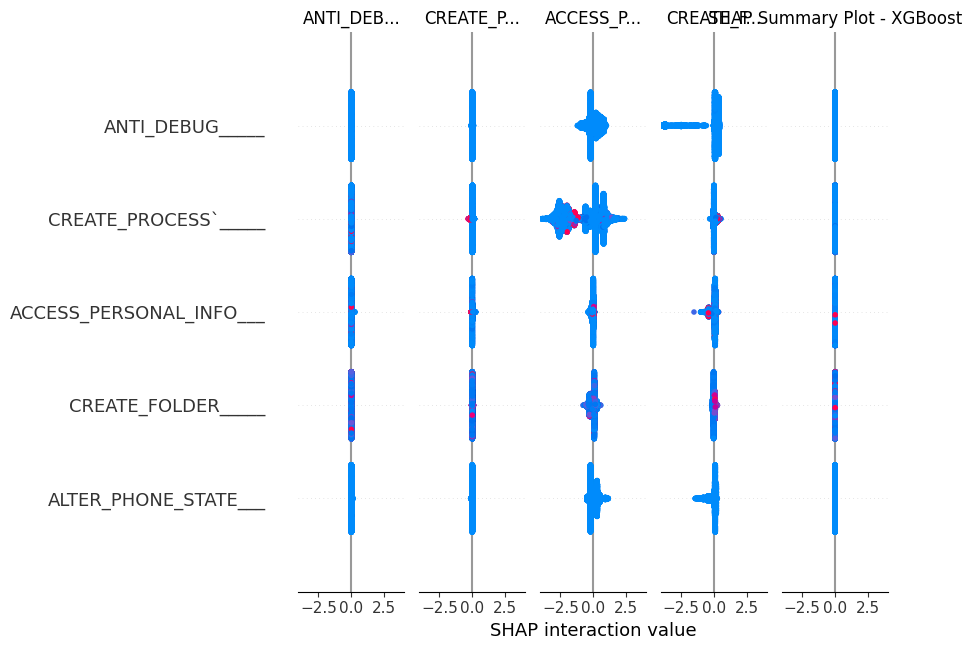

In [42]:
import shap
import matplotlib.pyplot as plt
import numpy as np
# ── 2. SHAP untuk XGBoost ────────────────────────────────────
print("\n--- SHAP Analysis: XGBoost ---")
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)

plt.figure()
shap.summary_plot(
    shap_values_xgb, X_train,
    class_names=class_labels,
    show=False
)
plt.title("SHAP Summary Plot - XGBoost")
plt.tight_layout()
plt.savefig("shap_xgb_summary.png", dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ── SHAP dari X_train, bukan X_test ──────────────────────────
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)  # ✅ ganti ke X_train

if shap_values_xgb.ndim == 3:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=(0, 2))
else:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=0)

shap_xgb_df = pd.DataFrame({
    'Feature'        : X_train.columns,  # ✅ ganti ke X_train
    'SHAP_Importance': shap_xgb_mean
}).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
print("\nTop 20 Features (XGBoost - SHAP):")
print(shap_xgb_df.head(20).to_string(index=False))



Top 20 Features (XGBoost - SHAP):
                Feature  SHAP_Importance
               mprotect         0.301531
                pread64         0.273091
                 access         0.268268
            getDeviceId         0.266653
         getDisplayInfo         0.261518
            sigprocmask         0.232564
ACCESS_PERSONAL_INFO___         0.227592
                   read         0.215841
                 writev         0.182678
                    brk         0.182536
getInstallerPackageName         0.171450
                  flock         0.157980
                 munmap         0.149079
                  mkdir         0.148359
          FS_ACCESS____         0.132000
        getSubscriberId         0.129960
                  write         0.129879
                lstat64         0.127451
     getActivePhoneType         0.124625
           gettimeofday         0.124372


In [ ]:
import numpy as np
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import classification_report
import pandas as pd

# ── 1. Definisi persentil & SMOTE variants ───────────────────────────────────
percentiles = [10, 20, 30, 40, 50, 60, 70]
from sklearn.preprocessing import MinMaxScaler

smote_variants = {
    'SMOTETomek'      : SMOTETomek(random_state=42),
}

# ── 2. Loop persentil × SMOTE ────────────────────────────────────────────────
results_all = {}

for P in percentiles:
    # Hitung N fitur
    N_total    = len(shap_xgb_df)
    N_FEATURES = int(np.ceil(N_total * P / 100))

    # Ambil fitur
    selected_features = shap_xgb_df.head(N_FEATURES)['Feature'].tolist()

    X_train_p = X_train[selected_features]
    X_test_p  = X_test[selected_features]

    print(f"\n{'='*60}")
    print(f"  Persentil P={P}% → {N_FEATURES} fitur")
    print(f"{'='*60}")

    for smote_name, sampler in smote_variants.items():
        print(f"\n  [{smote_name}]")

        # Resample X_train
        X_res, y_res = sampler.fit_resample(X_train_p, y_train)
        print(f"  Shape train : {X_train_p.shape} → {X_res.shape}")
        
        # Normaliszation
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_res)
        X_test_scaled  = scaler.transform(X_test_p)

        # Retrain model
        xgb_ps = XGBClassifier(**xgb_model.get_params())
        xgb_ps.fit(X_train_scaled, y_res)

        # Evaluasi di test asli (tidak di-resample)
        y_pred = xgb_ps.predict(X_test_scaled)
        report = classification_report(y_test, y_pred, output_dict=True)

        print(classification_report(y_test, y_pred))

        # Simpan hasil
        key = f'P{P}_{smote_name}'
        results_all[key] = {
            'Persentil'   : P,
            'N Fitur'     : N_FEATURES,
            'SMOTE'       : smote_name,
            'Accuracy'    : report['accuracy'],
            'F1 Macro'    : report['macro avg']['f1-score'],
            'F1 Weighted' : report['weighted avg']['f1-score'],
            'Precision'   : report['macro avg']['precision'],
            'Recall'      : report['macro avg']['recall'],
        }

# ── 3. Tabel perbandingan ────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())

# ── 4. Kombinasi terbaik ─────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Persentil : {best['Persentil']}%")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   SMOTE     : {best['SMOTE']}")
print(f"   F1 Macro  : {best['F1 Macro']}")


  Persentil P=10% → 47 fitur

  [SMOTETomek]
  Shape train : (9278, 47) → (15487, 47)
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       251
           1       0.95      0.92      0.93       420
           2       0.98      0.99      0.98       781
           3       0.96      0.92      0.94       509
           4       0.93      0.95      0.94       359

    accuracy                           0.95      2320
   macro avg       0.94      0.94      0.94      2320
weighted avg       0.95      0.95      0.95      2320


  Persentil P=20% → 94 fitur

  [SMOTETomek]
  Shape train : (9278, 94) → (15497, 94)
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       251
           1       0.95      0.91      0.93       420
           2       0.98      0.99      0.98       781
           3       0.96      0.93      0.94       509
           4       0.93      0.96      0.94       359

    accurac

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd

# ── 1. Definisi persentil & model ───────────────────────────────────────────
percentiles = [10, 20, 30, 40, 50, 60, 70]

models = {
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.2,
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=None,
        learning_rate=0.2,
        class_weight='balanced',
        random_state=42,
        verbose = -1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    )
}

sampler = SMOTETomek(random_state=42)


  Persentil P=10% → 47 fitur
  Shape train : (9278, 47) → (15487, 47)

  [XGBoost]
  Training Time : 2.6964s
  Testing Time  : 0.0076s
              precision    recall  f1-score   support

           2       0.86      0.93      0.89       251
           1       0.95      0.92      0.93       420
           0       0.98      0.99      0.98       781
           3       0.96      0.92      0.94       509
           4       0.93      0.95      0.94       359

    accuracy                           0.95      2320
   macro avg       0.94      0.94      0.94      2320
weighted avg       0.95      0.95      0.95      2320



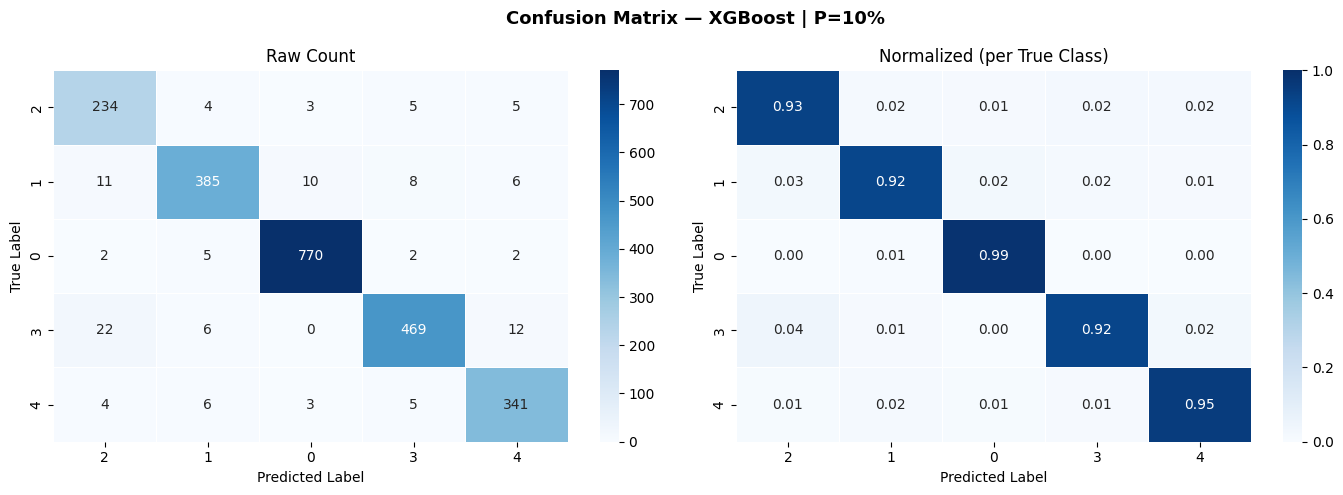


  [LightGBM]
  Training Time : 7.1416s
  Testing Time  : 0.0572s
              precision    recall  f1-score   support

           2       0.87      0.94      0.90       251
           1       0.94      0.91      0.93       420
           0       0.98      0.99      0.98       781
           3       0.97      0.92      0.94       509
           4       0.92      0.95      0.94       359

    accuracy                           0.95      2320
   macro avg       0.94      0.94      0.94      2320
weighted avg       0.95      0.95      0.95      2320



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


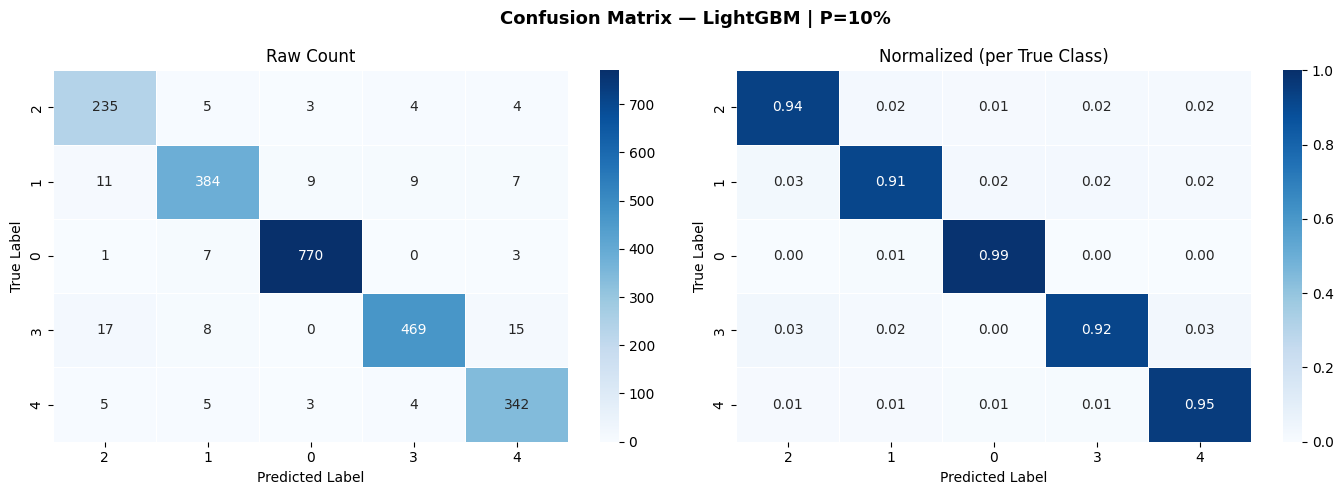


  [RandomForest]
  Training Time : 4.4013s
  Testing Time  : 0.0427s
              precision    recall  f1-score   support

           2       0.83      0.94      0.88       251
           1       0.96      0.90      0.93       420
           0       0.98      0.98      0.98       781
           3       0.97      0.92      0.94       509
           4       0.90      0.95      0.93       359

    accuracy                           0.94      2320
   macro avg       0.93      0.94      0.93      2320
weighted avg       0.95      0.94      0.95      2320



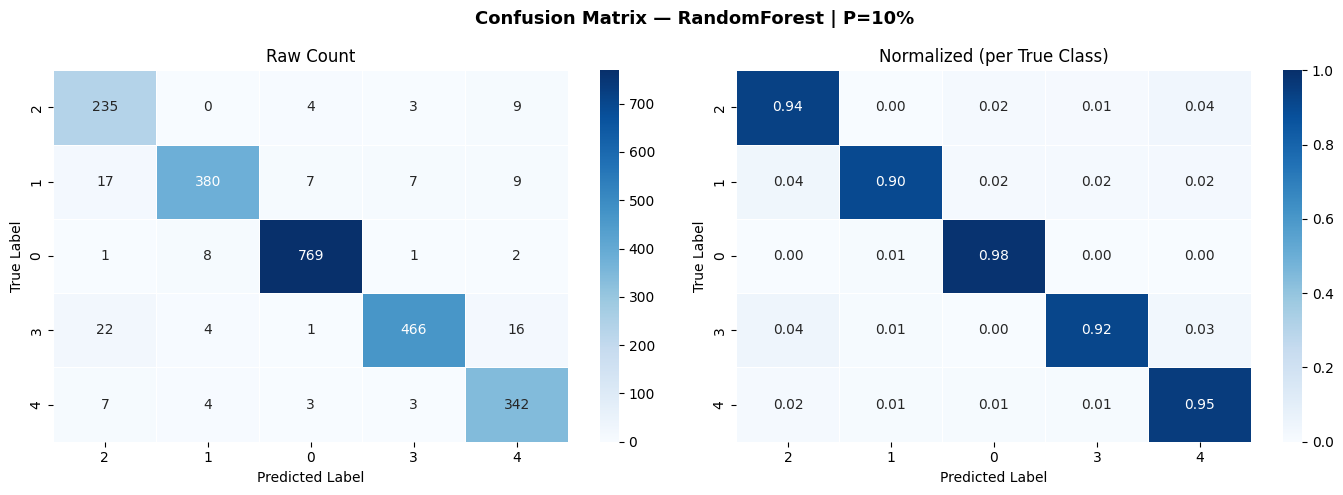


  Persentil P=20% → 94 fitur
  Shape train : (9278, 94) → (15497, 94)

  [XGBoost]
  Training Time : 3.8455s
  Testing Time  : 0.0079s
              precision    recall  f1-score   support

           2       0.87      0.93      0.90       251
           1       0.95      0.91      0.93       420
           0       0.98      0.99      0.98       781
           3       0.96      0.93      0.94       509
           4       0.93      0.96      0.94       359

    accuracy                           0.95      2320
   macro avg       0.94      0.94      0.94      2320
weighted avg       0.95      0.95      0.95      2320



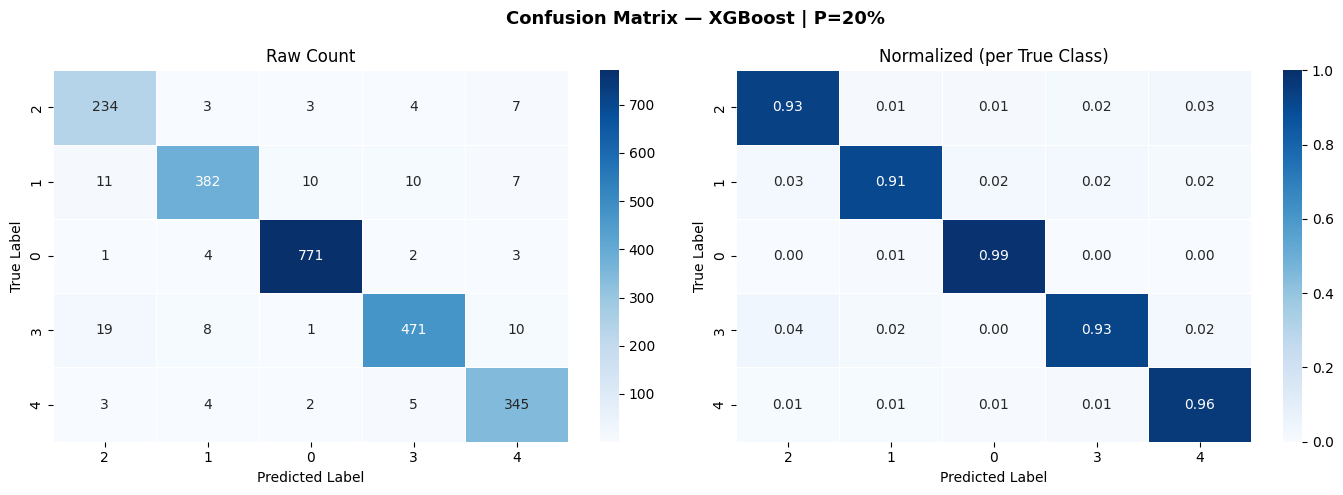


  [LightGBM]
  Training Time : 7.4244s
  Testing Time  : 0.0521s
              precision    recall  f1-score   support

           2       0.88      0.94      0.91       251
           1       0.96      0.91      0.94       420
           0       0.98      0.99      0.99       781
           3       0.97      0.93      0.95       509
           4       0.93      0.97      0.95       359

    accuracy                           0.95      2320
   macro avg       0.94      0.95      0.95      2320
weighted avg       0.96      0.95      0.95      2320



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


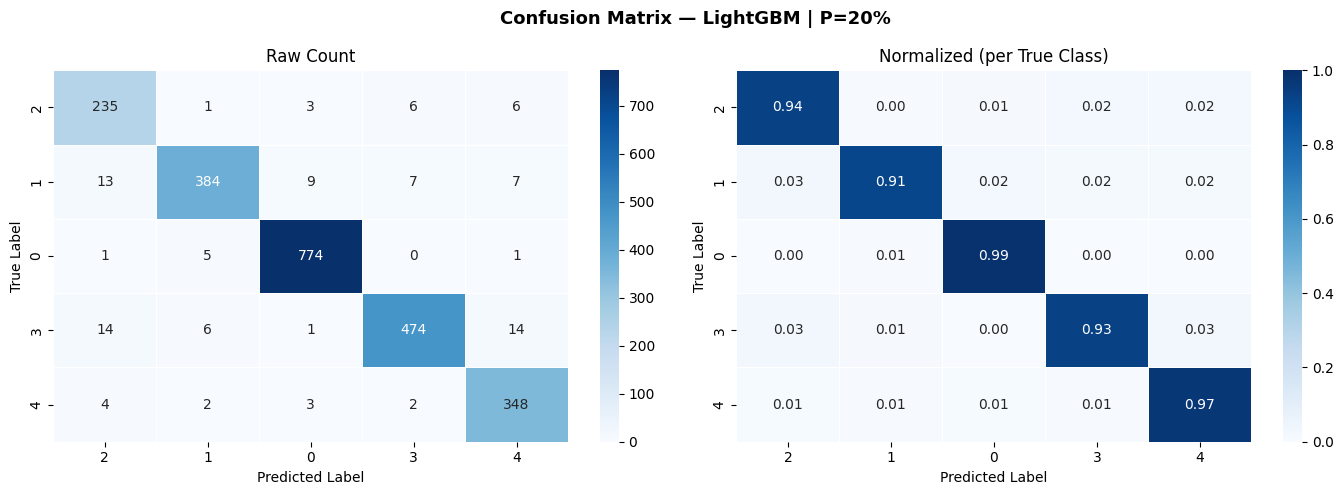


  [RandomForest]
  Training Time : 5.8992s
  Testing Time  : 0.0420s
              precision    recall  f1-score   support

           2       0.84      0.93      0.88       251
           1       0.96      0.90      0.93       420
           0       0.98      0.99      0.98       781
           3       0.97      0.91      0.94       509
           4       0.90      0.95      0.93       359

    accuracy                           0.94      2320
   macro avg       0.93      0.94      0.93      2320
weighted avg       0.95      0.94      0.94      2320



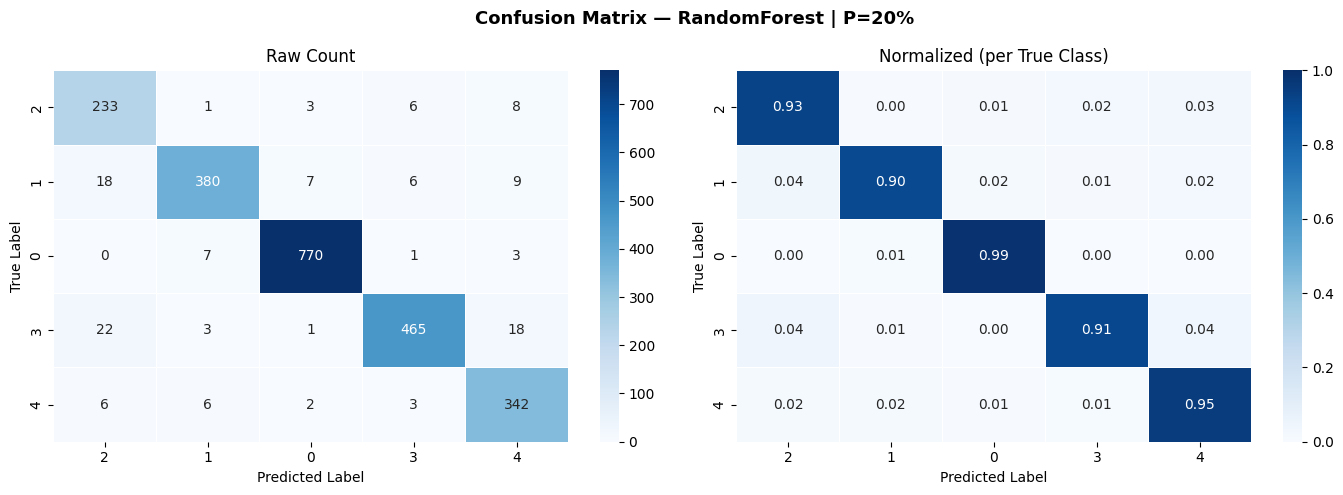


  Persentil P=30% → 141 fitur
  Shape train : (9278, 141) → (15503, 141)

  [XGBoost]
  Training Time : 3.9981s
  Testing Time  : 0.0073s
              precision    recall  f1-score   support

           2       0.88      0.94      0.91       251
           1       0.96      0.91      0.93       420
           0       0.98      0.99      0.98       781
           3       0.96      0.92      0.94       509
           4       0.93      0.97      0.95       359

    accuracy                           0.95      2320
   macro avg       0.94      0.95      0.94      2320
weighted avg       0.95      0.95      0.95      2320



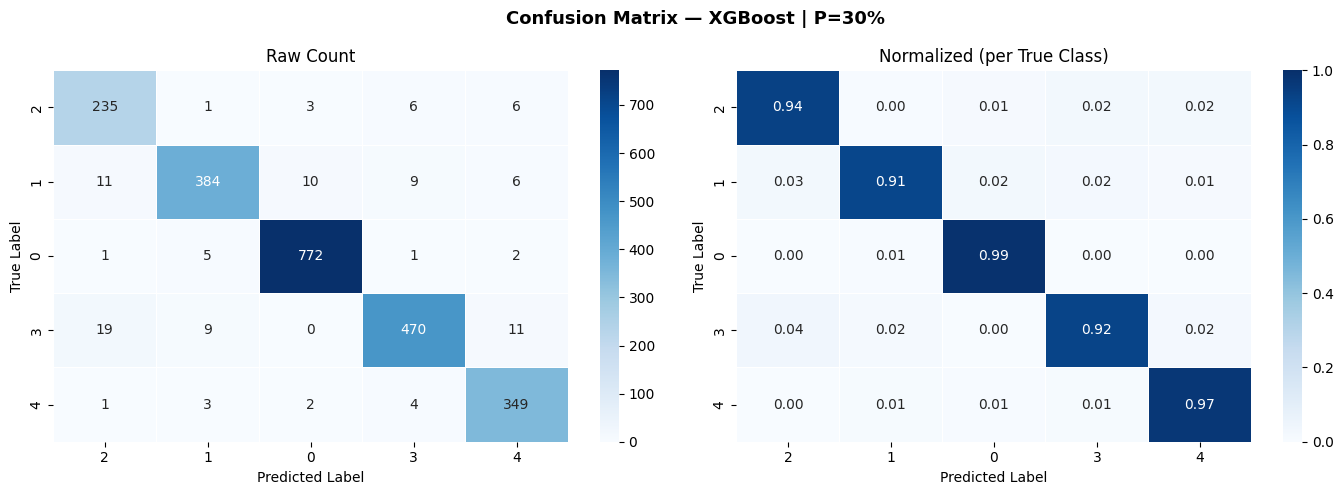


  [LightGBM]
  Training Time : 6.9439s
  Testing Time  : 0.0562s
              precision    recall  f1-score   support

           2       0.90      0.93      0.91       251
           1       0.96      0.92      0.94       420
           0       0.98      0.99      0.99       781
           3       0.96      0.93      0.94       509
           4       0.92      0.96      0.94       359

    accuracy                           0.95      2320
   macro avg       0.94      0.95      0.94      2320
weighted avg       0.95      0.95      0.95      2320



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


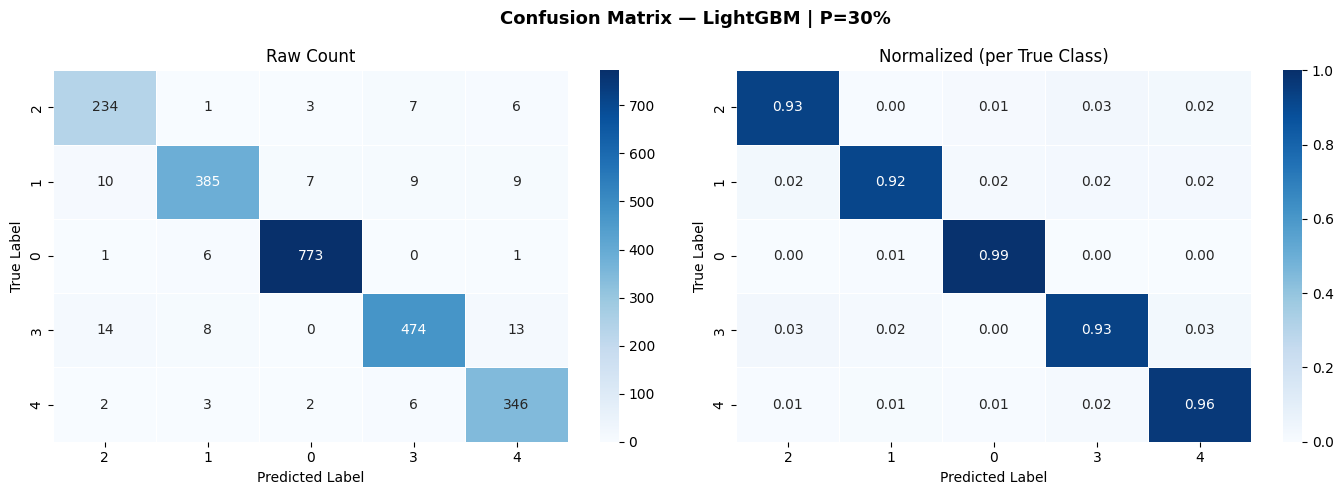


  [RandomForest]
  Training Time : 5.8267s
  Testing Time  : 0.0413s
              precision    recall  f1-score   support

           2       0.85      0.94      0.89       251
           1       0.95      0.90      0.93       420
           0       0.98      0.98      0.98       781
           3       0.96      0.92      0.94       509
           4       0.90      0.96      0.93       359

    accuracy                           0.94      2320
   macro avg       0.93      0.94      0.93      2320
weighted avg       0.95      0.94      0.95      2320



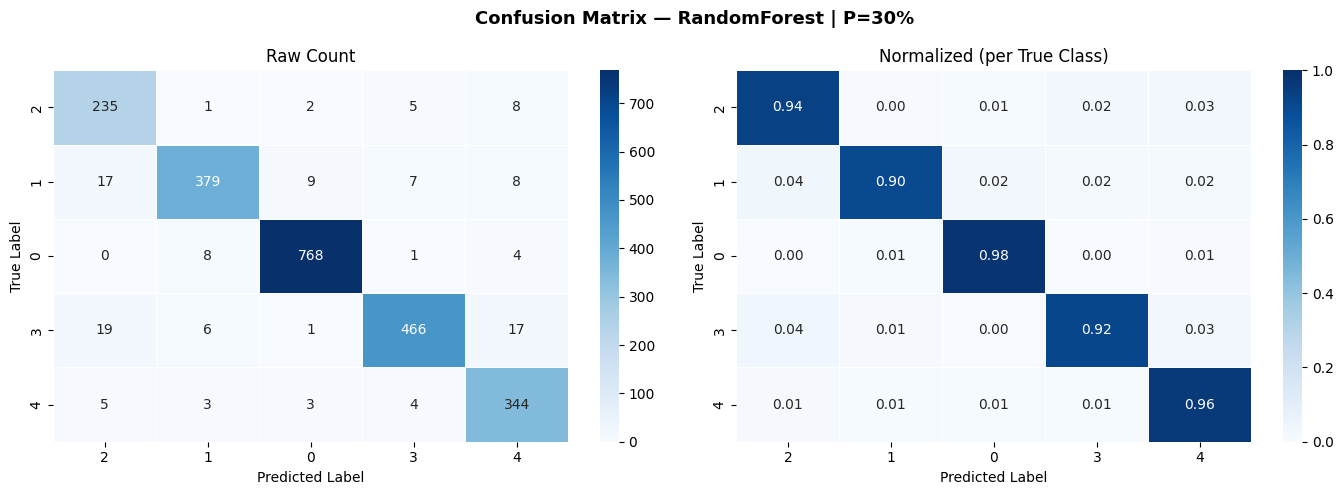


  Persentil P=40% → 188 fitur
  Shape train : (9278, 188) → (15501, 188)

  [XGBoost]
  Training Time : 4.0831s
  Testing Time  : 0.0068s
              precision    recall  f1-score   support

           2       0.88      0.94      0.91       251
           1       0.96      0.91      0.93       420
           0       0.98      0.99      0.98       781
           3       0.96      0.93      0.95       509
           4       0.93      0.96      0.95       359

    accuracy                           0.95      2320
   macro avg       0.94      0.95      0.94      2320
weighted avg       0.95      0.95      0.95      2320



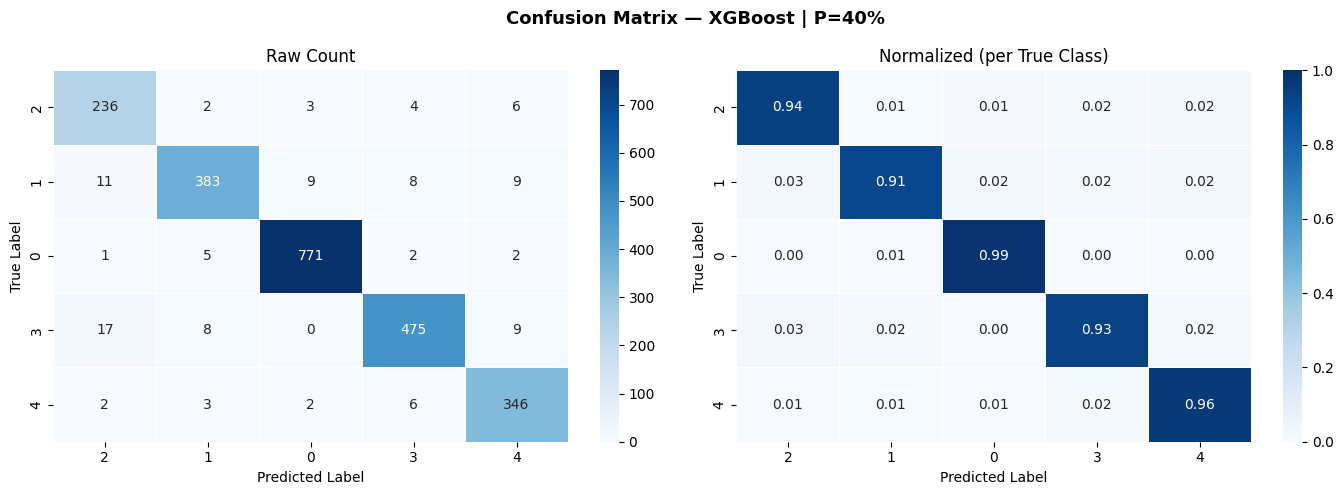


  [LightGBM]
  Training Time : 7.1639s
  Testing Time  : 0.0483s
              precision    recall  f1-score   support

           2       0.89      0.93      0.91       251
           1       0.96      0.91      0.93       420
           0       0.98      0.99      0.99       781
           3       0.96      0.93      0.95       509
           4       0.92      0.98      0.95       359

    accuracy                           0.95      2320
   macro avg       0.94      0.95      0.95      2320
weighted avg       0.95      0.95      0.95      2320



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


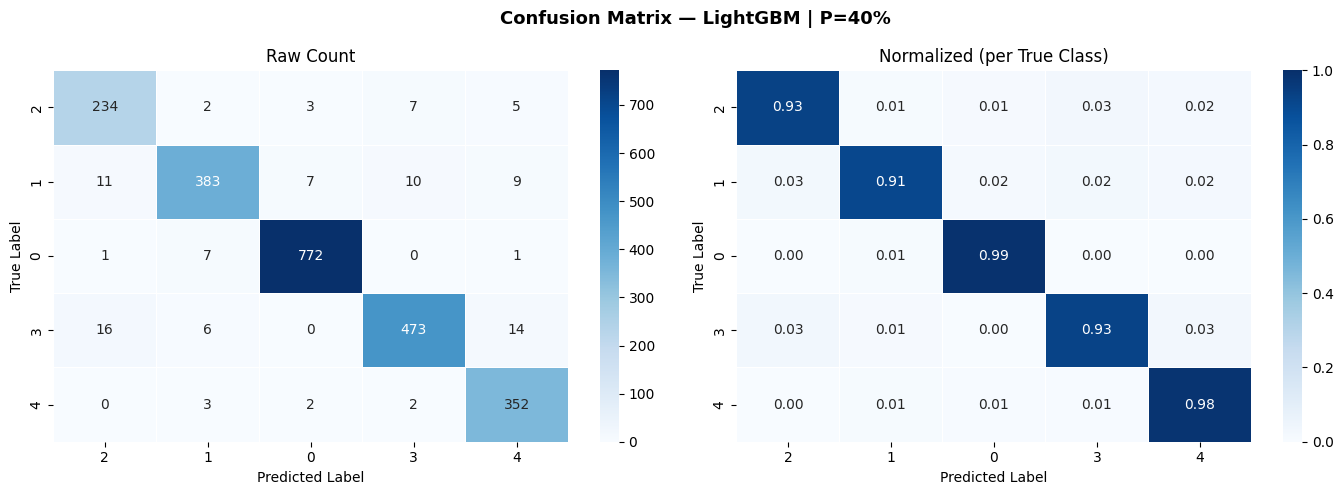


  [RandomForest]
  Training Time : 5.6115s
  Testing Time  : 0.0421s
              precision    recall  f1-score   support

           2       0.84      0.94      0.89       251
           1       0.97      0.90      0.93       420
           0       0.98      0.98      0.98       781
           3       0.96      0.92      0.94       509
           4       0.90      0.95      0.93       359

    accuracy                           0.94      2320
   macro avg       0.93      0.94      0.93      2320
weighted avg       0.95      0.94      0.95      2320



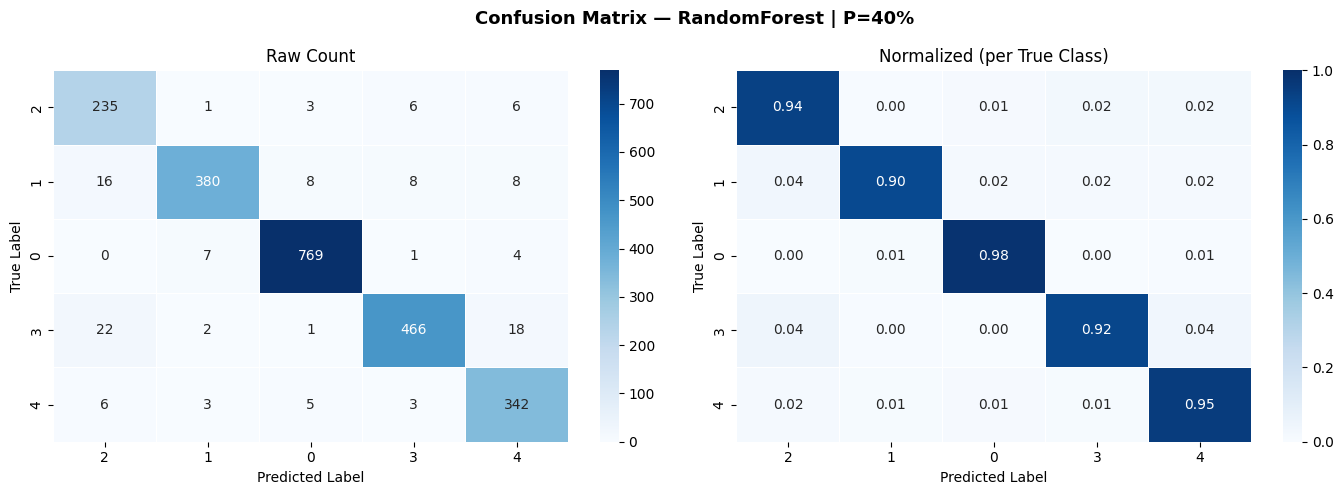


  Persentil P=50% → 235 fitur
  Shape train : (9278, 235) → (15501, 235)

  [XGBoost]
  Training Time : 4.3464s
  Testing Time  : 0.0075s
              precision    recall  f1-score   support

           2       0.90      0.94      0.92       251
           1       0.95      0.92      0.93       420
           0       0.98      0.99      0.98       781
           3       0.96      0.93      0.94       509
           4       0.94      0.97      0.95       359

    accuracy                           0.95      2320
   macro avg       0.94      0.95      0.95      2320
weighted avg       0.95      0.95      0.95      2320



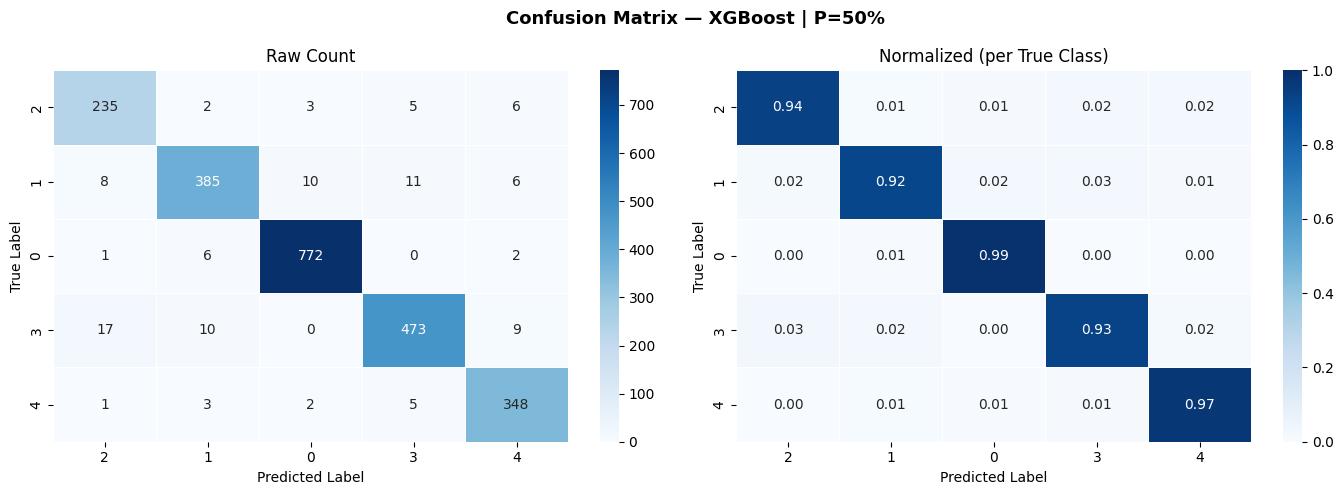


  [LightGBM]
  Training Time : 7.2744s
  Testing Time  : 0.0457s
              precision    recall  f1-score   support

           2       0.91      0.93      0.92       251
           1       0.95      0.92      0.93       420
           0       0.98      0.99      0.99       781
           3       0.95      0.94      0.94       509
           4       0.93      0.96      0.95       359

    accuracy                           0.95      2320
   macro avg       0.94      0.95      0.95      2320
weighted avg       0.95      0.95      0.95      2320



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


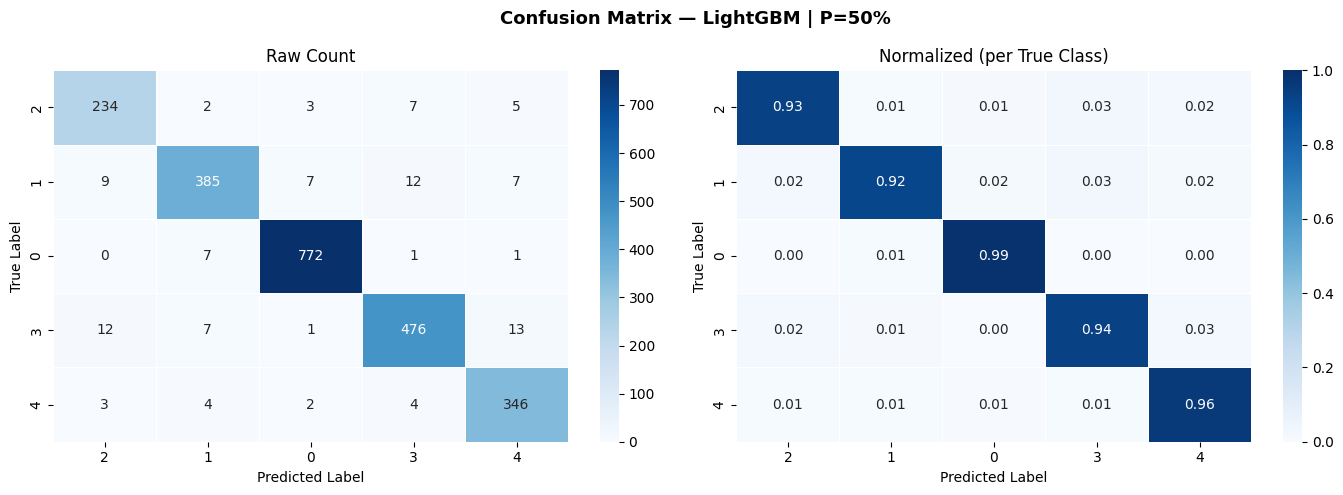


  [RandomForest]
  Training Time : 5.4840s
  Testing Time  : 0.0427s
              precision    recall  f1-score   support

           2       0.84      0.93      0.88       251
           1       0.96      0.90      0.93       420
           0       0.98      0.99      0.98       781
           3       0.96      0.91      0.94       509
           4       0.90      0.95      0.93       359

    accuracy                           0.94      2320
   macro avg       0.93      0.94      0.93      2320
weighted avg       0.95      0.94      0.94      2320



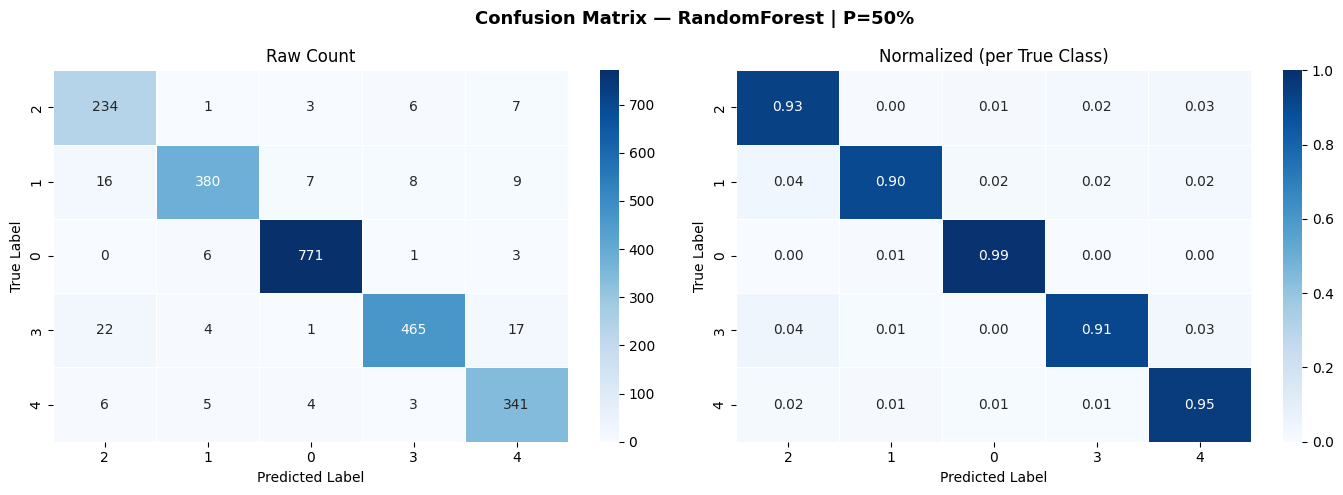


  Persentil P=60% → 282 fitur
  Shape train : (9278, 282) → (15501, 282)

  [XGBoost]
  Training Time : 4.7080s
  Testing Time  : 0.0069s
              precision    recall  f1-score   support

           2       0.89      0.94      0.91       251
           1       0.94      0.92      0.93       420
           0       0.98      0.99      0.99       781
           3       0.96      0.93      0.94       509
           4       0.94      0.96      0.95       359

    accuracy                           0.95      2320
   macro avg       0.94      0.95      0.94      2320
weighted avg       0.95      0.95      0.95      2320



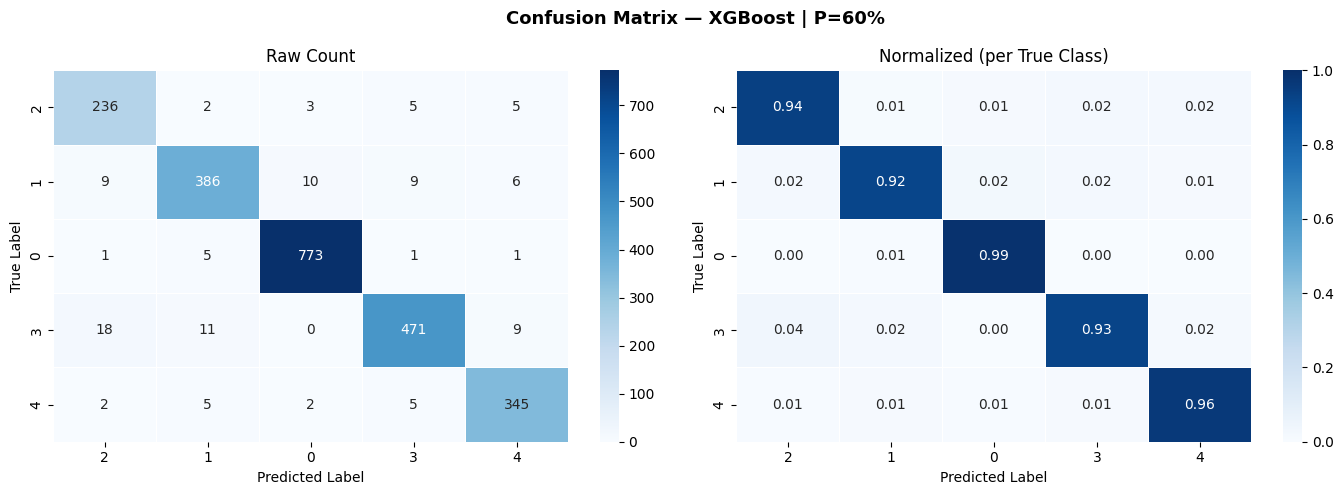


  [LightGBM]
  Training Time : 8.5435s
  Testing Time  : 0.0468s
              precision    recall  f1-score   support

           2       0.90      0.93      0.92       251
           1       0.96      0.93      0.94       420
           0       0.99      0.99      0.99       781
           3       0.97      0.93      0.94       509
           4       0.92      0.98      0.95       359

    accuracy                           0.96      2320
   macro avg       0.95      0.95      0.95      2320
weighted avg       0.96      0.96      0.96      2320



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


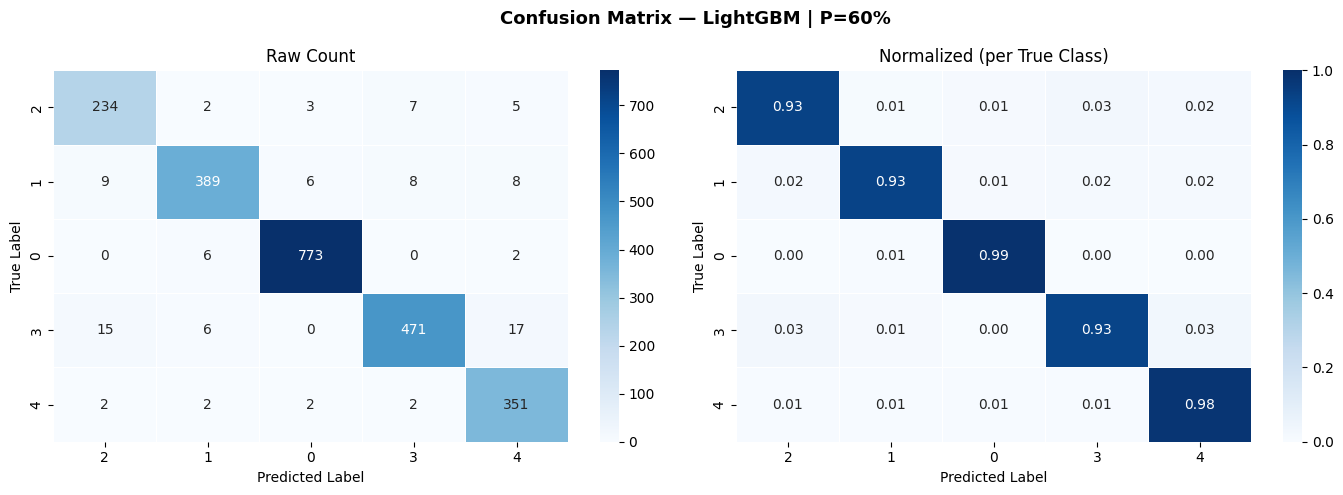


  [RandomForest]
  Training Time : 5.1379s
  Testing Time  : 0.0429s
              precision    recall  f1-score   support

           2       0.85      0.93      0.89       251
           1       0.95      0.90      0.93       420
           0       0.98      0.99      0.98       781
           3       0.97      0.91      0.94       509
           4       0.89      0.96      0.92       359

    accuracy                           0.94      2320
   macro avg       0.93      0.94      0.93      2320
weighted avg       0.95      0.94      0.94      2320



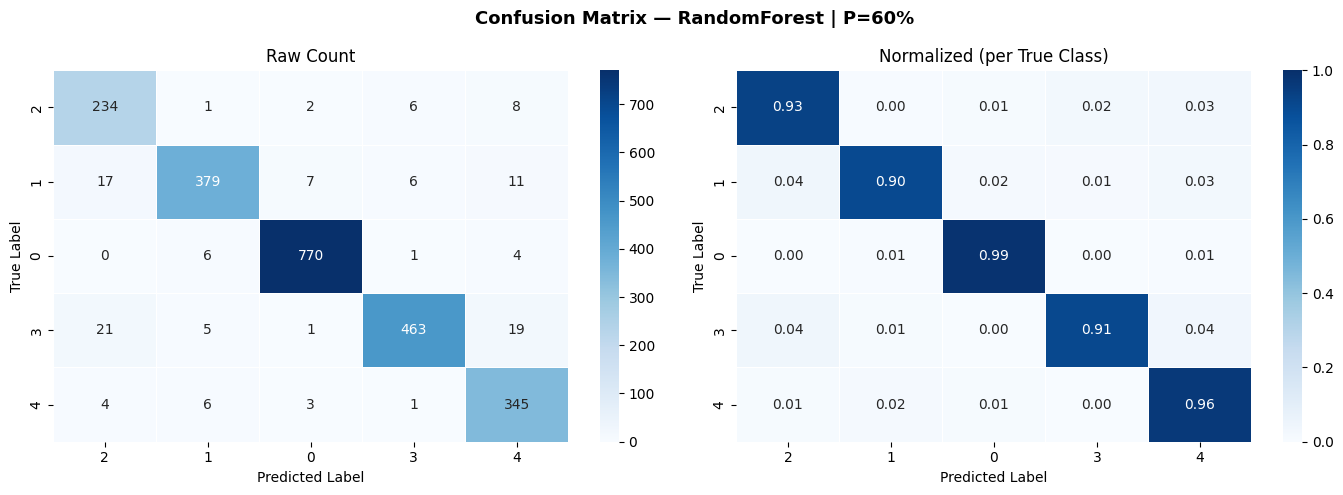


  Persentil P=70% → 329 fitur
  Shape train : (9278, 329) → (15501, 329)

  [XGBoost]
  Training Time : 4.8532s
  Testing Time  : 0.0075s
              precision    recall  f1-score   support

           2       0.88      0.94      0.91       251
           1       0.96      0.91      0.93       420
           0       0.98      0.99      0.99       781
           3       0.96      0.92      0.94       509
           4       0.93      0.97      0.95       359

    accuracy                           0.95      2320
   macro avg       0.94      0.95      0.94      2320
weighted avg       0.95      0.95      0.95      2320



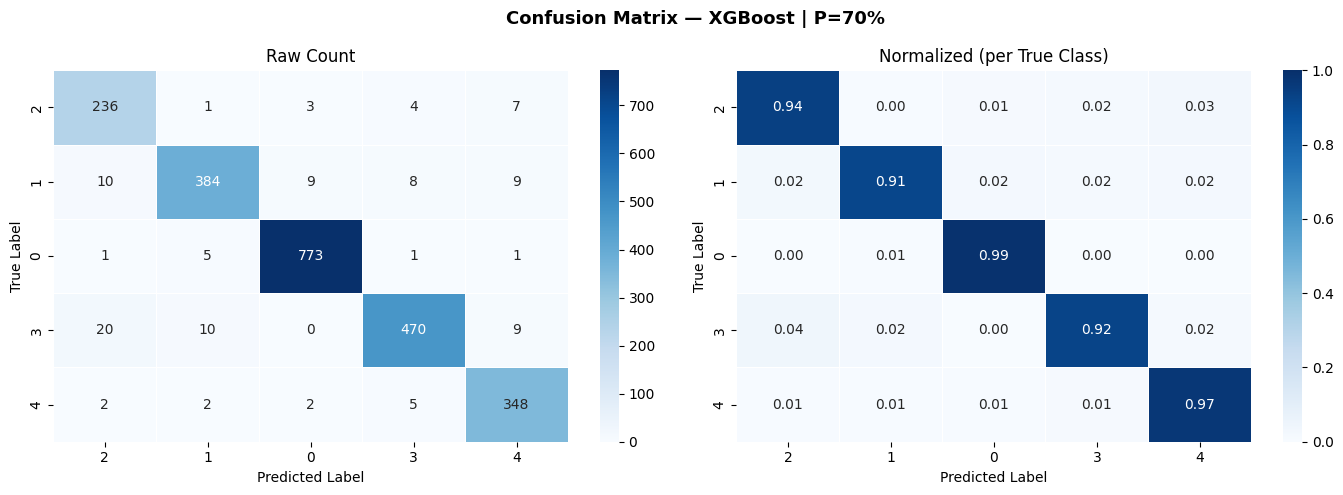


  [LightGBM]
  Training Time : 7.3305s
  Testing Time  : 0.0447s
              precision    recall  f1-score   support

           2       0.90      0.93      0.91       251
           1       0.95      0.92      0.93       420
           0       0.99      0.99      0.99       781
           3       0.97      0.93      0.95       509
           4       0.92      0.97      0.95       359

    accuracy                           0.96      2320
   macro avg       0.94      0.95      0.95      2320
weighted avg       0.96      0.96      0.96      2320



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


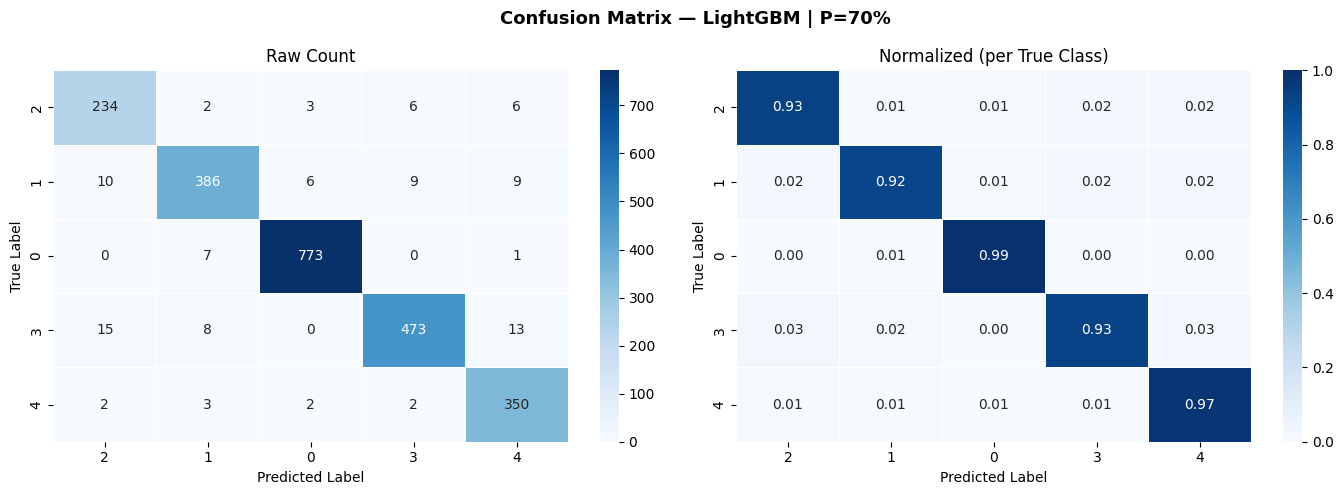


  [RandomForest]
  Training Time : 5.1794s
  Testing Time  : 0.0443s
              precision    recall  f1-score   support

           2       0.84      0.93      0.89       251
           1       0.96      0.90      0.93       420
           0       0.98      0.99      0.98       781
           3       0.97      0.91      0.94       509
           4       0.90      0.96      0.93       359

    accuracy                           0.94      2320
   macro avg       0.93      0.94      0.93      2320
weighted avg       0.95      0.94      0.94      2320



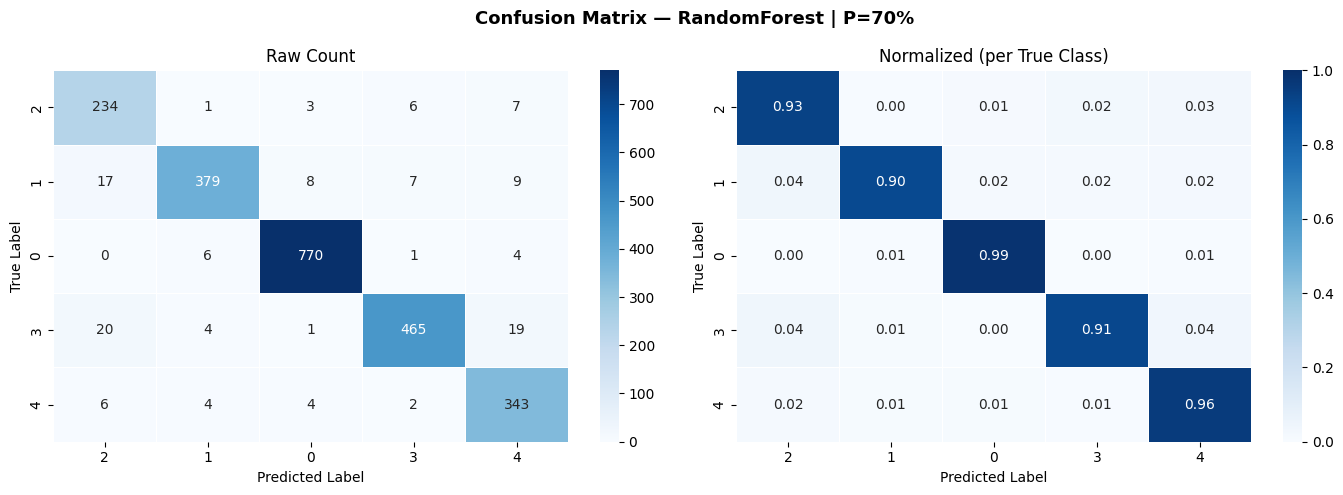


── Perbandingan Semua Kombinasi (SMOTETomek) ──
                 Persentil N Fitur         Model  Accuracy  F1 Macro F1 Weighted Precision Macro Precision Weighted Recall Macro Recall Weighted Training Time Testing Time
P60_LightGBM            60     282      LightGBM  0.956034  0.947533    0.956051        0.945615           0.956734     0.950256        0.956034        8.5435       0.0468
P70_LightGBM            70     329      LightGBM  0.955172  0.946401    0.955173         0.94441           0.955715     0.949056        0.955172        7.3305       0.0447
P50_XGBoost             50     235       XGBoost  0.953879  0.945934     0.95383        0.944332           0.954151     0.948006        0.953879        4.3464       0.0075
P50_LightGBM            50     235      LightGBM  0.953879  0.945778    0.953837        0.944628           0.954075     0.947274        0.953879        7.2744       0.0457
P20_LightGBM            20      94      LightGBM  0.954741  0.945682    0.954778        0.9

In [46]:
# ── 2. Helper plot confusion matrix ─────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, percentile, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — {model_name} | P={percentile}%', fontsize=13, fontweight='bold')

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[0], linewidths=0.5
    )
    axes[0].set_title('Raw Count')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[1], linewidths=0.5, vmin=0, vmax=1
    )
    axes[1].set_title('Normalized (per True Class)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

# ── 3. Loop persentil × model ────────────────────────────────────────────────
results_all = {}

for P in percentiles:
    N_total    = len(shap_xgb_df)
    N_FEATURES = int(np.ceil(N_total * P / 100))

    selected_features = shap_xgb_df.head(N_FEATURES)['Feature'].tolist()

    X_train_p = X_train[selected_features]
    X_test_p  = X_test[selected_features]

    X_res, y_res = sampler.fit_resample(X_train_p, y_train)

    print(f"\n{'='*60}")
    print(f"  Persentil P={P}% → {N_FEATURES} fitur")
    print(f"  Shape train : {X_train_p.shape} → {X_res.shape}")
    print(f"{'='*60}")

    for model_name, clf in models.items():
        print(f"\n  [{model_name}]")

        clf_fit = clf.__class__(**clf.get_params())

        # Normalization
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_res)
        X_test_scaled  = scaler.transform(X_test_p)

        start = time.time()
        clf_fit.fit(X_train_scaled, y_res)
        train_time = time.time() - start
        print(f"  Training Time : {train_time:.4f}s")

        # ── Testing Time ────────────────────────────────────────────────────
        start = time.time()
        y_pred = clf_fit.predict(X_test_scaled)
        test_time = time.time() - start
        print(f"  Testing Time  : {test_time:.4f}s")

        report = classification_report(y_test, y_pred, output_dict=True)
        print(classification_report(y_test, y_pred, target_names=[str(x) for x in class_labels]))

        # ── Confusion Matrix ────────────────────────────────────────────────
        plot_confusion_matrix(y_test, y_pred, model_name, P, class_labels)

        key = f'P{P}_{model_name}'
        results_all[key] = {
            'Persentil'          : P,
            'N Fitur'            : N_FEATURES,
            'Model'              : model_name,
            'Accuracy'           : report['accuracy'],
            'F1 Macro'           : report['macro avg']['f1-score'],
            'F1 Weighted'        : report['weighted avg']['f1-score'],
            'Precision Macro'    : report['macro avg']['precision'],
            'Precision Weighted' : report['weighted avg']['precision'],
            'Recall Macro'       : report['macro avg']['recall'],
            'Recall Weighted'    : report['weighted avg']['recall'],
            'Training Time'      : round(train_time, 4),
            'Testing Time'       : round(test_time, 4),
        }

# ── 4. Tabel perbandingan ────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi (SMOTETomek) ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())

# ── 5. Kombinasi terbaik ─────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Persentil : {best['Persentil']}%")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   Model     : {best['Model']}")
print(f"   F1 Macro  : {best['F1 Macro']}")